In [1]:
from pathlib import Path
import shutil
import subprocess

import ipynbname
import contextily as cx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
from matplotlib.lines import Line2D
from shapely.geometry import box

REPO_ROOT = Path(ipynbname.path()).parent.parent
DATA_ROOT = REPO_ROOT / "data"
COMMUNES_PATH = DATA_ROOT / "processed" / "shapefiles" / "communes_2021.gpkg"
POP_GRID_PATH = DATA_ROOT / "raw" / "pop" / "poland_bbox_pop_100m.parquet"


def _kpsewhich(name: str) -> str:
    if not shutil.which("kpsewhich"):
        return ""
    return subprocess.run(
        ["kpsewhich", name], capture_output=True, text=True
    ).stdout.strip()


# Matplotlib usetex always loads type1cm.sty; shim to cm-super type1ec if needed.
if not _kpsewhich("type1cm.sty"):
    shim_dir = Path.home() / "texmf" / "tex" / "latex" / "type1cm"
    shim_dir.mkdir(parents=True, exist_ok=True)
    (shim_dir / "type1cm.sty").write_text(
        "% Shim for matplotlib usetex: map type1cm -> cm-super type1ec.\n"
        "\\ProvidesPackage{type1cm}\n"
        "\\RequirePackage{type1ec}\n"
    )

# LaTeX preamble (T1 needed for Polish \k{} ogonek; siunitx optional on lean TeX Live)
_latex_preamble = r"\usepackage[T1]{fontenc}\usepackage{amsmath}\usepackage{amssymb}"
if _kpsewhich("siunitx.sty"):
    _latex_preamble += r"\usepackage{siunitx}[=v2]"

sns.set_style("whitegrid")
plt.rcParams.update({
    # 'figure.figsize': (6*2, 2*4.5),
    "font.size": 16.0,
    "font.family": "serif",
    "font.serif": "Palatino",
    "axes.titlesize": "medium",
    "figure.titlesize": "large",
    "legend.fontsize": "medium",
    # dpi for high-res output
    "figure.dpi": 100,
    "savefig.dpi": 300,
    # Tight layout by default
    "figure.autolayout": True,
    "text.usetex": True,
    "text.latex.preamble": _latex_preamble,
})

# Polish characters -> LaTeX accents (pdflatex / usetex cannot take raw Unicode here)
_PL_LATEX = {
    "ą": r"\k{a}", "ć": r"\'c", "ę": r"\k{e}", "ł": r"\l{}",
    "ń": r"\'n", "ó": r"\'o", "ś": r"\'s", "ź": r"\'z", "ż": r"\.{z}",
    "Ą": r"\k{A}", "Ć": r"\'C", "Ę": r"\k{E}", "Ł": r"\L{}",
    "Ń": r"\'N", "Ó": r"\'O", "Ś": r"\'S", "Ź": r"\'Z", "Ż": r"\.{Z}",
}


def _fix_utf8_mojibake(s: str) -> str:
    """Undo UTF-8 bytes mis-decoded as Latin-1 (common with PRG shapefiles)."""
    try:
        return s.encode("latin1").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return s


def latex_text(s: str) -> str:
    s = _fix_utf8_mojibake(str(s))
    for ch, rep in _PL_LATEX.items():
        s = s.replace(ch, rep)
    return s.replace("_", r"\_").replace("&", r"\&").replace("%", r"\%")


In [2]:
fpi = gpd.read_file(DATA_ROOT / "processed" / "floorspace" / "gmina_floorspace_index_2021.gpkg")

DataSourceError: /Users/jedrek/Documents/Studium Volkswirschaftslehre/4. Semester/Quantitive Spatial Economics/QSE_paper.nosync/QSE_Poland_paper/data/processed/floorspace/gmina_floorspace_index_2021.gpkg: No such file or directory

In [ ]:
fpi.sort_values(by="index_zl_m2", ascending=False, inplace=True)
fpi['index_demeaned'] = (fpi['index_zl_m2'] - fpi['index_zl_m2'].mean()) / fpi['index_zl_m2'].std()
fpi['rank'] = fpi['index_zl_m2'].rank(method='min', ascending=False).astype(int)
fpi.head(10)

,gmina_teryt,pop_x,nazwa,powiat,rodz_class,index_zl_m2,theta_tilde,theta_sd,shrinkage_to_data,has_rcn,n_obs,n_flats,n_houses,gus_median,land_ppm2,land_level,pop_y,geometry,index_demeaned,rank
1420,2211023,3435,Jastarnia,2211,urban_rural,12946.733164,9.468599,0.027961,0.992093,True,470.0,408,62,7123.0,767.775838,gmina,3435,"MULTIPOLYGON (((469644.614 765763.479, 469663....",8.200423,1
157,2264011,31877,Sopot,2264,urban,12016.668910,9.394050,0.005434,0.999701,True,7207.0,6895,312,14233.0,1249.856078,gmina,31877,"MULTIPOLYGON (((473466.277 729634.34, 473454.1...",7.446844,2
2358,3207043,5953,Międzyzdroje,3207,urban_rural,11679.084768,9.365555,0.014680,0.997820,True,939.0,891,48,11047.0,202.121505,powiat,5953,"MULTIPOLYGON (((211492.333 689173.792, 211648....",7.173318,3
689,1405021,3567,Podkowa Leśna,1405,urban,10742.051448,9.281921,0.082223,0.931663,True,28.0,3,25,5723.0,206.587050,powiat,3567,"MULTIPOLYGON (((622229.734 470724.375, 622229....",6.414093,4
780,1217042,8432,Kościelisko,1217,rural,10445.527737,9.253929,0.021850,0.995171,True,663.0,436,227,11027.0,393.753419,gmina,8432,"MULTIPOLYGON (((559952.637 165233.771, 559958....",6.173837,5
469,1217011,24678,Zakopane,1217,urban,9921.086039,9.202418,0.011681,0.998620,True,2607.0,2006,601,11027.0,608.065843,gmina,24678,"MULTIPOLYGON (((571595.415 163010.122, 571613....",5.748911,6
1539,1465011,1861075,Warszawa,1465,urban,9130.803592,9.119409,0.002262,0.999948,True,143784.0,133463,10321,10495.0,879.038115,gmina,1861075,"MULTIPOLYGON (((628292.098 492055.177, 628292....",5.108589,7
2063,2210011,1126,Krynica Morska,2210,urban,9024.347733,9.107682,0.018692,0.996466,True,526.0,419,107,5274.0,96.415876,powiat,1126,"MULTIPOLYGON (((541417.4 732888.942, 541477.71...",5.022334,8
1410,1211042,6768,Czorsztyn,1211,rural,8742.407034,9.075941,0.083545,0.929411,True,29.0,16,13,6011.0,85.299548,powiat,6768,"MULTIPOLYGON (((590719.854 181498.429, 590733....",4.793894,9
502,3207013,3554,Dziwnów,3207,urban_rural,8721.860757,9.073588,0.011171,0.998738,True,1043.0,990,53,11047.0,202.121505,powiat,3554,"MULTIPOLYGON (((231477.147 695592.611, 231498....",4.777246,10


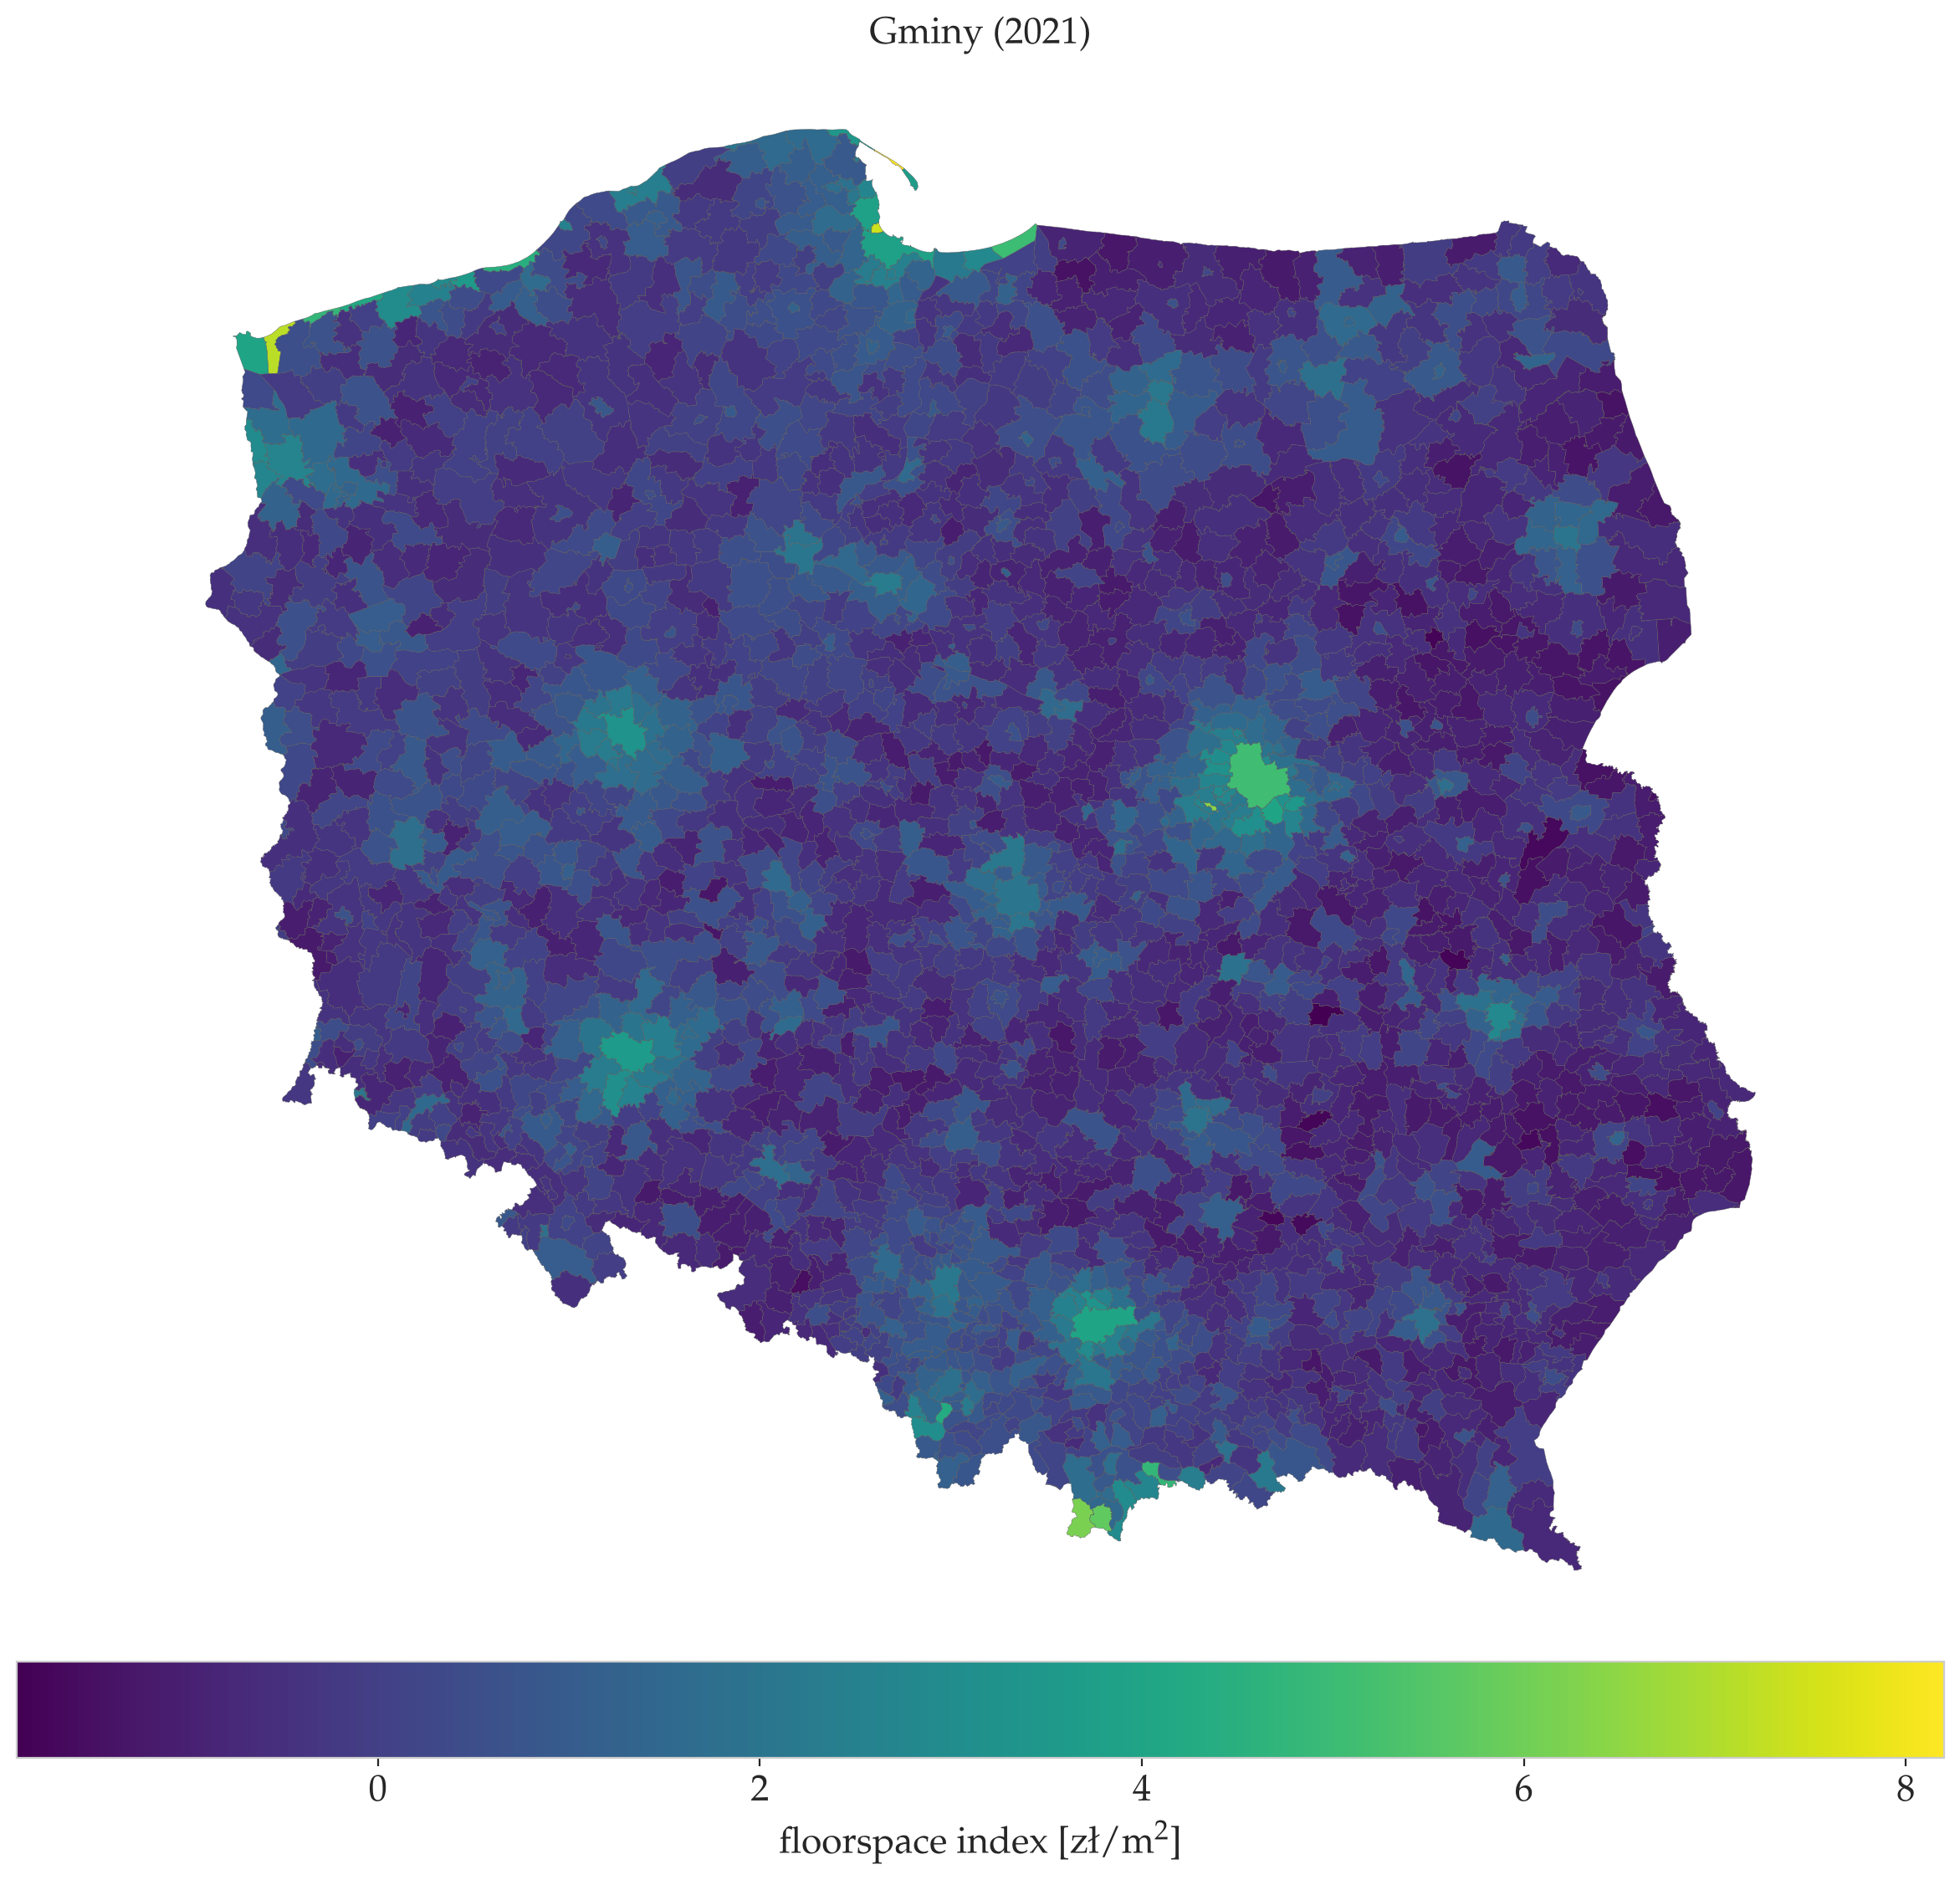

In [ ]:
fig, ax = plt.subplots(figsize=(12, 12))

# adjust dpi to 200
fig.set_dpi(200)

# Plot the communes from fpi with column "index_zl_m2" on a viridis scale
fpi.plot(
    ax=ax,
    column="index_demeaned",
    cmap="viridis",
    linewidth=0.15,
    edgecolor="0.35",
)

# plot the colorbar
sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=fpi["index_demeaned"].min(), vmax=fpi["index_demeaned"].max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation="horizontal", pad=0.01)
cbar.set_label(r"floorspace index [zł/m$^2$]")

ax.set_axis_off()
ax.set_aspect("equal")
ax.set_title(r"Gminy (2021)")
fig.tight_layout()
plt.show()